In [37]:
!pip install pandas matplotlib seaborn scikit-learn

In [38]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configuration
BASE_RESULTS_DIR = "baseline_results"

print("Baseline QA Results Analysis")
print("=" * 50)

Baseline QA Results Analysis


In [39]:
def load_results_data():
    """Load all results from the baseline_results directory structure."""
    results_data = defaultdict(lambda: defaultdict(list))
    
    # Walk through all level directories
    for level_dir in os.listdir(BASE_RESULTS_DIR):
        if not level_dir.startswith("level_"):
            continue
        level = int(level_dir.split("_")[1])
        
        level_path = os.path.join(BASE_RESULTS_DIR, level_dir)
        if not os.path.isdir(level_path):
            continue
            
        print(f"Processing level {level}...")
        
        # Walk through all image directories
        for image_dir in os.listdir(level_path):
            image_path = os.path.join(level_path, image_dir)
            if not os.path.isdir(image_path):
                continue
                
            # Walk through all strategy directories
            for strategy_dir in os.listdir(image_path):
                if not strategy_dir.startswith("strategy_"):
                    continue
                strategy = int(strategy_dir.split("_")[1])  # Extract number from "strategy_X_timestamp"
                
                strategy_path = os.path.join(image_path, strategy_dir)
                if not os.path.isdir(strategy_path):
                    continue
                    
                # Look for overview/results.json
                results_file = os.path.join(strategy_path, "overview", "results.json")
                if os.path.exists(results_file):
                    with open(results_file, 'r') as f:
                        data = json.load(f)
                        
                    results_data[level][strategy].append({
                        'image_id': image_dir,
                        'results': data['results'],
                        'accuracy': data['accuracy'],
                        'timestamp': data['timestamp']
                    })
    
    return results_data

# Load all results
results_data = load_results_data()
print(f"\nLoaded results for {len(results_data)} levels")
for level in sorted(results_data.keys()):
    for strategy in sorted(results_data[level].keys()):
        print(f"  Level {level}, Strategy {strategy}: {len(results_data[level][strategy])} images")

Processing level 5...
Processing level 1...
Processing level 1...
Processing level 3...
Processing level 3...
Processing level 6...
Processing level 6...
Processing level 4...
Processing level 4...
Processing level 0...
Processing level 0...
Processing level 2...
Processing level 2...

Loaded results for 7 levels
  Level 0, Strategy 0: 40 images
  Level 0, Strategy 1: 40 images
  Level 0, Strategy 2: 40 images
  Level 0, Strategy 3: 40 images
  Level 0, Strategy 4: 40 images
  Level 1, Strategy 0: 40 images
  Level 1, Strategy 1: 40 images
  Level 1, Strategy 2: 40 images
  Level 1, Strategy 3: 40 images
  Level 1, Strategy 4: 40 images
  Level 2, Strategy 0: 40 images
  Level 2, Strategy 1: 40 images
  Level 2, Strategy 2: 40 images
  Level 2, Strategy 3: 40 images
  Level 2, Strategy 4: 40 images
  Level 3, Strategy 0: 40 images
  Level 3, Strategy 1: 40 images
  Level 3, Strategy 2: 40 images
  Level 3, Strategy 3: 40 images
  Level 3, Strategy 4: 40 images
  Level 4, Strategy 0: 40

In [40]:
def create_confusion_matrix_data(results_data):
    """Create confusion matrix data for each strategy and level."""
    confusion_data = defaultdict(lambda: defaultdict(lambda: {'y_true': [], 'y_pred': []}))
    
    for level in results_data:
        for strategy in results_data[level]:
            for image_data in results_data[level][strategy]:
                for question in image_data['results']:
                    gt = question['gt']  # ground truth
                    pred = question['prediction']  # model prediction
                    
                    confusion_data[level][strategy]['y_true'].append(gt)
                    confusion_data[level][strategy]['y_pred'].append(pred)
    
    return confusion_data

# Create confusion matrix data
confusion_data = create_confusion_matrix_data(results_data)
print("Created confusion matrix data for analysis")

Created confusion matrix data for analysis


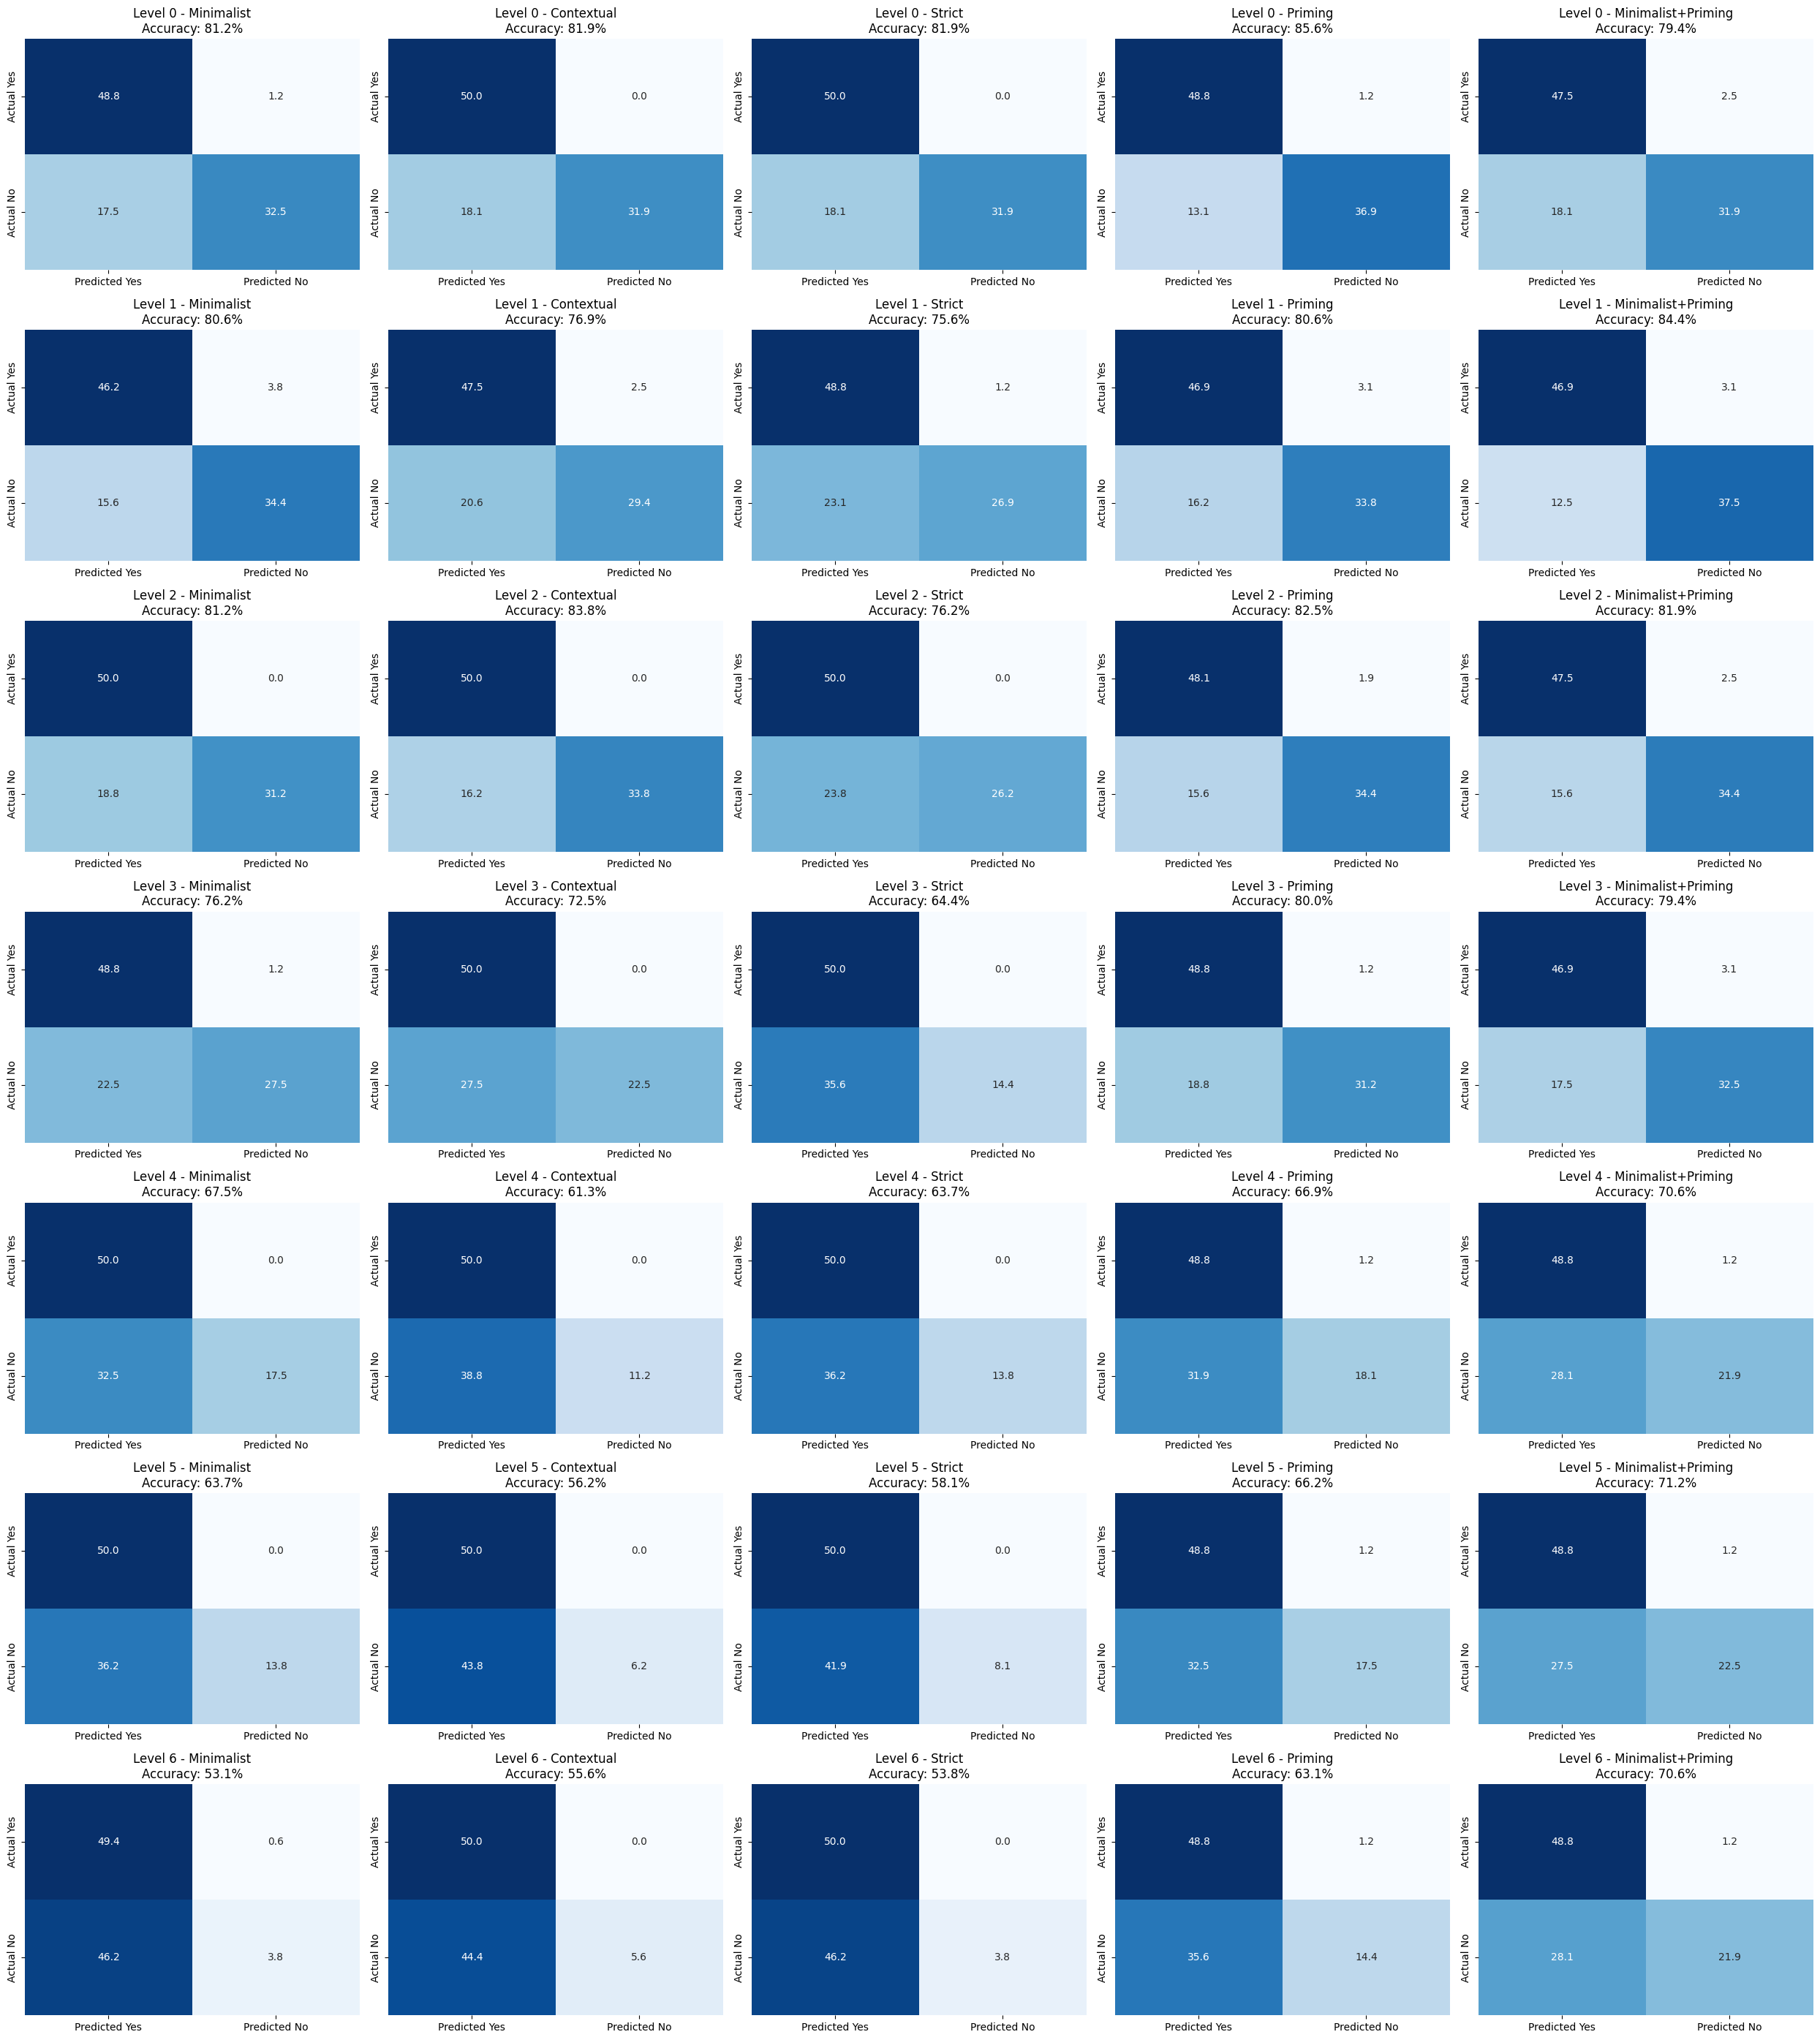

In [41]:
def plot_confusion_matrices(confusion_data):
    """Plot confusion matrices for each strategy and level."""
    levels = sorted(confusion_data.keys())
    strategies = sorted(set(strategy for level_data in confusion_data.values() 
                           for strategy in level_data.keys()))
    
    n_levels = len(levels)
    n_strategies = len(strategies)
    
    fig, axes = plt.subplots(n_levels, n_strategies, figsize=(5*n_strategies, 4*n_levels))
    if n_levels == 1 and n_strategies == 1:
        axes = np.array([[axes]])
    elif n_levels == 1:
        axes = axes.reshape(1, -1)
    elif n_strategies == 1:
        axes = axes.reshape(-1, 1)
    
    strategy_names = {
        0: "Minimalist",
        1: "Contextual", 
        2: "Strict",
        3: "Priming",
        4: "Minimalist+Priming"
    }
    
    for i, level in enumerate(levels):
        for j, strategy in enumerate(strategies):
            ax = axes[i, j]
            
            if strategy in confusion_data[level]:
                y_true = confusion_data[level][strategy]['y_true']
                y_pred = confusion_data[level][strategy]['y_pred']
                
                # Create confusion matrix
                cm = confusion_matrix(y_true, y_pred, labels=['yes', 'no'])
                
                # Calculate percentages
                cm_percent = cm.astype('float') / cm.sum() * 100
                
                # Plot
                sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                           xticklabels=['Predicted Yes', 'Predicted No'],
                           yticklabels=['Actual Yes', 'Actual No'], ax=ax, cbar=False)
                
                # Calculate accuracy
                accuracy = np.trace(cm) / np.sum(cm) * 100
                ax.set_title(f'Level {level} - {strategy_names.get(strategy, f"Strategy {strategy}")}\nAccuracy: {accuracy:.1f}%')
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Level {level} - {strategy_names.get(strategy, f"Strategy {strategy}")}')
            
            ax.set_xlabel('')
            ax.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('baseline_qa_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot confusion matrices
plot_confusion_matrices(confusion_data)

In [42]:
def calculate_accuracy_stats(results_data):
    """Calculate accuracy statistics for each strategy and level."""
    stats = defaultdict(lambda: defaultdict(dict))
    
    for level in results_data:
        for strategy in results_data[level]:
            accuracies = [img_data['accuracy'] for img_data in results_data[level][strategy]]
            
            stats[level][strategy] = {
                'mean_accuracy': np.mean(accuracies) * 100,
                'std_accuracy': np.std(accuracies) * 100,
                'min_accuracy': np.min(accuracies) * 100,
                'max_accuracy': np.max(accuracies) * 100,
                'num_images': len(accuracies)
            }
    
    return stats

# Calculate statistics
accuracy_stats = calculate_accuracy_stats(results_data)

# Display as table
strategy_names = {0: "Minimalist", 1: "Contextual", 2: "Strict", 3: "Priming", 4: "Minimalist+Priming"}
print("\nAccuracy Statistics by Level and Strategy")
print("=" * 60)

for level in sorted(accuracy_stats.keys()):
    print(f"\nLevel {level}:")
    for strategy in sorted(accuracy_stats[level].keys()):
        stat = accuracy_stats[level][strategy]
        print(f"  {strategy_names.get(strategy, f'Strategy {strategy}')}: {stat['mean_accuracy']:.1f}% ± {stat['std_accuracy']:.1f}% "
              f"(min: {stat['min_accuracy']:.1f}%, max: {stat['max_accuracy']:.1f}%, n={stat['num_images']})")


Accuracy Statistics by Level and Strategy

Level 0:
  Minimalist: 81.2% ± 20.0% (min: 25.0%, max: 100.0%, n=40)
  Contextual: 81.9% ± 14.8% (min: 50.0%, max: 100.0%, n=40)
  Strict: 81.9% ± 17.7% (min: 50.0%, max: 100.0%, n=40)
  Priming: 85.6% ± 17.6% (min: 25.0%, max: 100.0%, n=40)
  Minimalist+Priming: 79.4% ± 20.1% (min: 25.0%, max: 100.0%, n=40)

Level 1:
  Minimalist: 80.6% ± 18.1% (min: 50.0%, max: 100.0%, n=40)
  Contextual: 76.9% ± 16.2% (min: 50.0%, max: 100.0%, n=40)
  Strict: 75.6% ± 17.2% (min: 50.0%, max: 100.0%, n=40)
  Priming: 80.6% ± 20.5% (min: 25.0%, max: 100.0%, n=40)
  Minimalist+Priming: 84.4% ± 16.5% (min: 50.0%, max: 100.0%, n=40)

Level 2:
  Minimalist: 81.2% ± 16.5% (min: 50.0%, max: 100.0%, n=40)
  Contextual: 83.8% ± 17.3% (min: 50.0%, max: 100.0%, n=40)
  Strict: 76.2% ± 18.5% (min: 50.0%, max: 100.0%, n=40)
  Priming: 82.5% ± 17.0% (min: 50.0%, max: 100.0%, n=40)
  Minimalist+Priming: 81.9% ± 15.8% (min: 50.0%, max: 100.0%, n=40)

Level 3:
  Minimalist: 

<Figure size 1200x600 with 0 Axes>

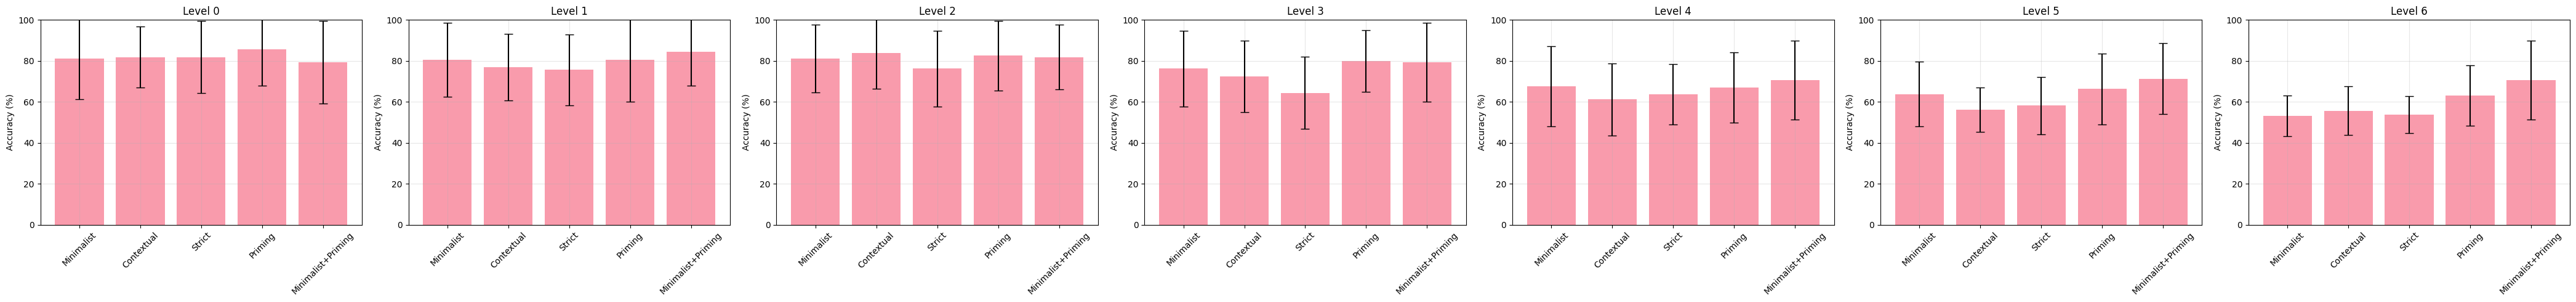

In [43]:
def plot_accuracy_comparison(accuracy_stats):
    """Plot accuracy comparison across strategies and levels."""
    levels = sorted(accuracy_stats.keys())
    strategies = sorted(set(strategy for level_data in accuracy_stats.values() 
                           for strategy in level_data.keys()))
    
    # Prepare data for plotting
    plot_data = []
    for level in levels:
        for strategy in strategies:
            if strategy in accuracy_stats[level]:
                plot_data.append({
                    'Level': f'Level {level}',
                    'Strategy': strategy_names.get(strategy, f'Strategy {strategy}'),
                    'Accuracy': accuracy_stats[level][strategy]['mean_accuracy'],
                    'Std': accuracy_stats[level][strategy]['std_accuracy']
                })
    
    df = pd.DataFrame(plot_data)
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    if len(levels) > 1:
        # Multiple levels - use subplots
        n_levels = len(levels)
        fig, axes = plt.subplots(1, n_levels, figsize=(6*n_levels, 5))
        
        for i, level in enumerate(levels):
            level_data = df[df['Level'] == f'Level {level}']
            if not level_data.empty:
                bars = axes[i].bar(range(len(level_data)), level_data['Accuracy'], 
                                  yerr=level_data['Std'], capsize=5, alpha=0.7)
                axes[i].set_title(f'Level {level}')
                axes[i].set_ylabel('Accuracy (%)')
                axes[i].set_xticks(range(len(level_data)))
                axes[i].set_xticklabels([s.split()[0] for s in level_data['Strategy']], rotation=45)
                axes[i].set_ylim(0, 100)
                axes[i].grid(True, alpha=0.3)
    else:
        # Single level
        bars = plt.bar(range(len(df)), df['Accuracy'], yerr=df['Std'], capsize=5, alpha=0.7)
        plt.ylabel('Accuracy (%)')
        plt.title(f'Baseline QA Accuracy by Strategy - {df["Level"].iloc[0]}')
        plt.xticks(range(len(df)), [s.split()[0] for s in df['Strategy']], rotation=45)
        plt.ylim(0, 100)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('baseline_qa_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot accuracy comparison
plot_accuracy_comparison(accuracy_stats)

In [44]:
def analyze_question_types(confusion_data):
    """Analyze performance on yes vs no questions."""
    question_analysis = defaultdict(lambda: defaultdict(lambda: {'yes_correct': 0, 'yes_total': 0, 'no_correct': 0, 'no_total': 0}))
    
    for level in confusion_data:
        for strategy in confusion_data[level]:
            y_true = confusion_data[level][strategy]['y_true']
            y_pred = confusion_data[level][strategy]['y_pred']
            
            for true, pred in zip(y_true, y_pred):
                if true == 'yes':
                    question_analysis[level][strategy]['yes_total'] += 1
                    if pred == 'yes':
                        question_analysis[level][strategy]['yes_correct'] += 1
                elif true == 'no':
                    question_analysis[level][strategy]['no_total'] += 1
                    if pred == 'no':
                        question_analysis[level][strategy]['no_correct'] += 1
    
    # Print analysis
    print("\nQuestion Type Analysis")
    print("=" * 50)
    
    for level in sorted(question_analysis.keys()):
        print(f"\nLevel {level}:")
        for strategy in sorted(question_analysis[level].keys()):
            data = question_analysis[level][strategy]
            yes_acc = data['yes_correct'] / data['yes_total'] * 100 if data['yes_total'] > 0 else 0
            no_acc = data['no_correct'] / data['no_total'] * 100 if data['no_total'] > 0 else 0
            
            print(f"  {strategy_names.get(strategy, f'Strategy {strategy}')}: "
                  f"Yes questions: {yes_acc:.1f}% ({data['yes_correct']}/{data['yes_total']}), "
                  f"No questions: {no_acc:.1f}% ({data['no_correct']}/{data['no_total']})")

# Analyze question types
analyze_question_types(confusion_data)


Question Type Analysis

Level 0:
  Minimalist: Yes questions: 97.5% (78/80), No questions: 65.0% (52/80)
  Contextual: Yes questions: 100.0% (80/80), No questions: 63.7% (51/80)
  Strict: Yes questions: 100.0% (80/80), No questions: 63.7% (51/80)
  Priming: Yes questions: 97.5% (78/80), No questions: 73.8% (59/80)
  Minimalist+Priming: Yes questions: 95.0% (76/80), No questions: 63.7% (51/80)

Level 1:
  Minimalist: Yes questions: 92.5% (74/80), No questions: 68.8% (55/80)
  Contextual: Yes questions: 95.0% (76/80), No questions: 58.8% (47/80)
  Strict: Yes questions: 97.5% (78/80), No questions: 53.8% (43/80)
  Priming: Yes questions: 93.8% (75/80), No questions: 67.5% (54/80)
  Minimalist+Priming: Yes questions: 93.8% (75/80), No questions: 75.0% (60/80)

Level 2:
  Minimalist: Yes questions: 100.0% (80/80), No questions: 62.5% (50/80)
  Contextual: Yes questions: 100.0% (80/80), No questions: 67.5% (54/80)
  Strict: Yes questions: 100.0% (80/80), No questions: 52.5% (42/80)
  Primi

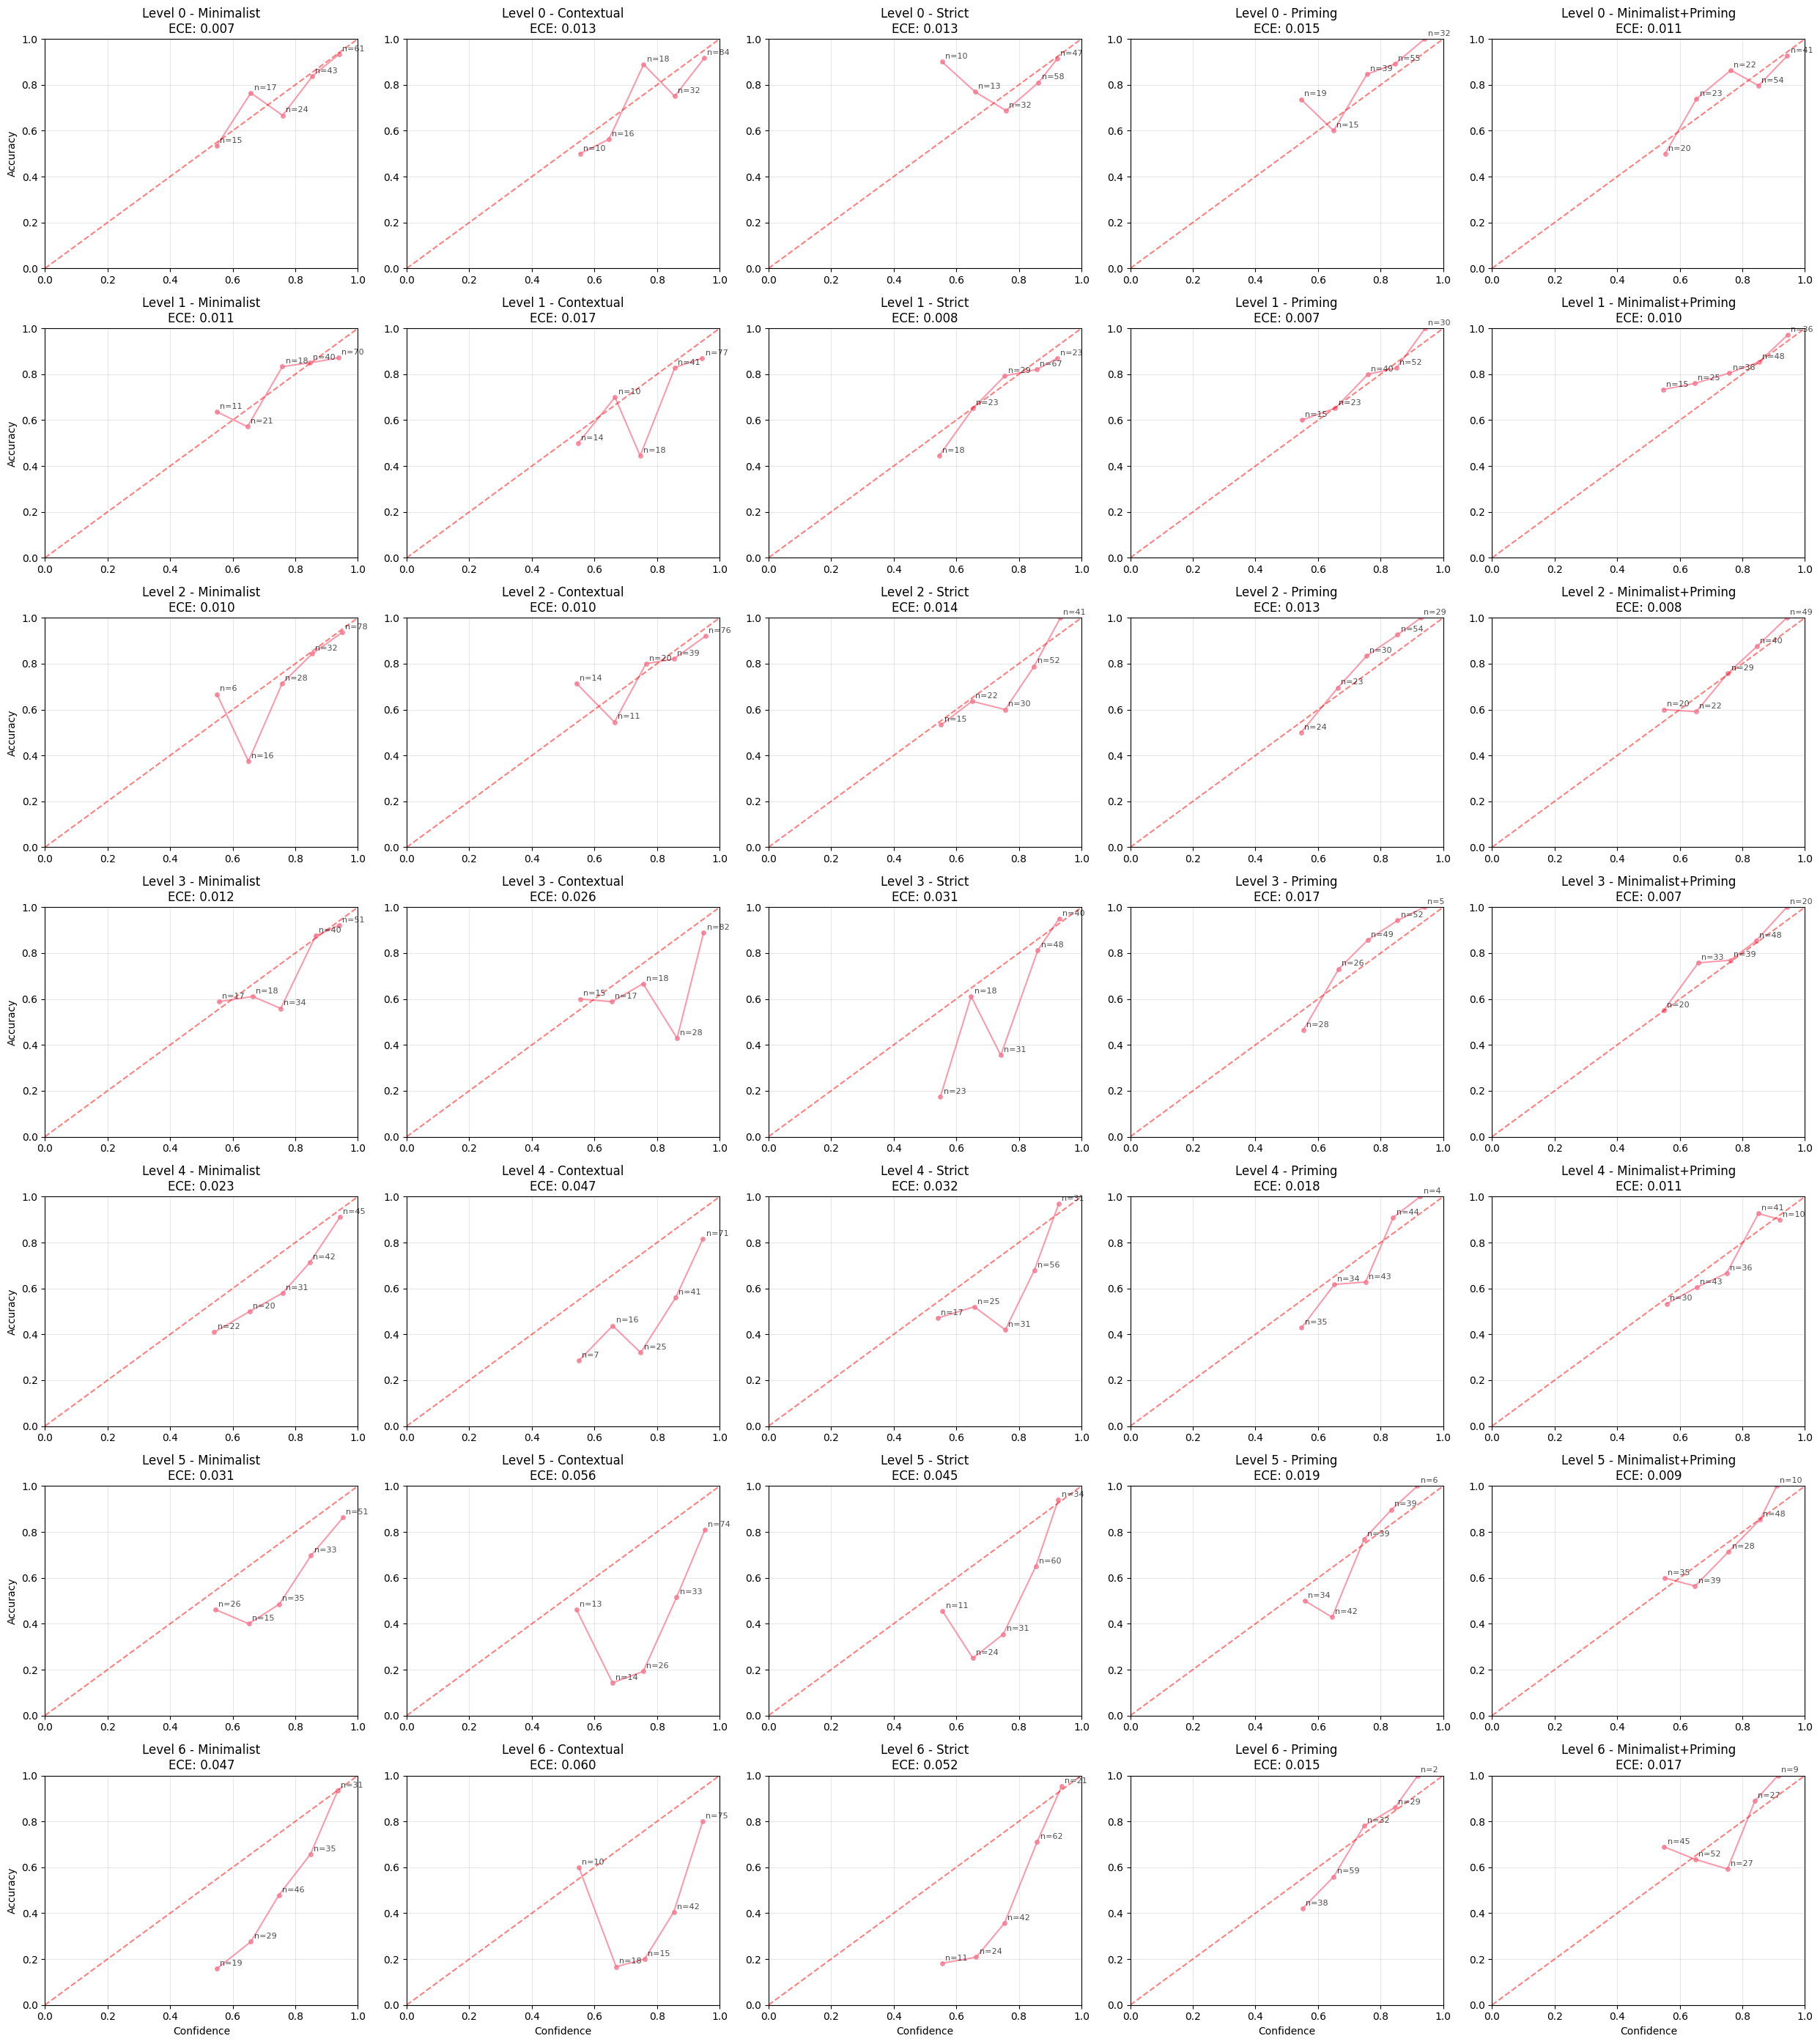

In [45]:
def analyze_calibration(results_data):
    """Analyze calibration - how well confidence matches accuracy."""
    calibration_data = defaultdict(lambda: defaultdict(list))
    
    # Collect confidence and correctness for each prediction
    for level in results_data:
        for strategy in results_data[level]:
            for image_data in results_data[level][strategy]:
                for question in image_data['results']:
                    confidence = question['confidence']  # 0-1 scale
                    is_correct = question['is_correct']
                    
                    calibration_data[level][strategy].append({
                        'confidence': confidence,
                        'correct': is_correct
                    })
    
    return calibration_data

def plot_calibration(calibration_data):
    """Plot calibration curves for each strategy and level."""
    levels = sorted(calibration_data.keys())
    strategies = sorted(set(strategy for level_data in calibration_data.values() 
                           for strategy in level_data.keys()))
    
    n_levels = len(levels)
    n_strategies = len(strategies)
    
    fig, axes = plt.subplots(n_levels, n_strategies, figsize=(5*n_strategies, 4*n_levels))
    if n_levels == 1 and n_strategies == 1:
        axes = np.array([[axes]])
    elif n_levels == 1:
        axes = axes.reshape(1, -1)
    elif n_strategies == 1:
        axes = axes.reshape(-1, 1)
    
    strategy_names = {
        0: "Minimalist",
        1: "Contextual", 
        2: "Strict",
        3: "Priming",
        4: "Minimalist+Priming"
    }
    
    for i, level in enumerate(levels):
        for j, strategy in enumerate(strategies):
            ax = axes[i, j]
            
            if strategy in calibration_data[level] and calibration_data[level][strategy]:
                data = calibration_data[level][strategy]
                
                # Bin confidence into 10 bins (0-10%, 10-20%, etc.)
                bins = np.linspace(0, 1, 11)
                bin_centers = (bins[:-1] + bins[1:]) / 2
                
                accuracies = []
                confidences = []
                counts = []
                
                for k in range(len(bins)-1):
                    bin_start, bin_end = bins[k], bins[k+1]
                    bin_data = [d for d in data if bin_start <= d['confidence'] < bin_end]
                    
                    if bin_data:
                        acc = np.mean([d['correct'] for d in bin_data])
                        conf = np.mean([d['confidence'] for d in bin_data])
                        accuracies.append(acc)
                        confidences.append(conf)
                        counts.append(len(bin_data))
                
                if accuracies:
                    # Plot calibration curve
                    ax.plot(confidences, accuracies, 'o-', alpha=0.7, markersize=4)
                    
                    # Perfect calibration line
                    ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect calibration')
                    
                    # Add count labels
                    for x, y, c in zip(confidences, accuracies, counts):
                        ax.annotate(f'n={c}', (x, y), xytext=(3, 3), 
                                  textcoords='offset points', fontsize=8, alpha=0.7)
                    
                    ax.set_xlim(0, 1)
                    ax.set_ylim(0, 1)
                    ax.grid(True, alpha=0.3)
                    
                    # Calculate ECE (Expected Calibration Error)
                    ece = np.mean([abs(acc - conf) * (count / len(data)) 
                                 for acc, conf, count in zip(accuracies, confidences, counts)])
                    
                    ax.set_title(f'Level {level} - {strategy_names.get(strategy, f"Strategy {strategy}")}\nECE: {ece:.3f}')
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(f'Level {level} - {strategy_names.get(strategy, f"Strategy {strategy}")}')
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Level {level} - {strategy_names.get(strategy, f"Strategy {strategy}")}')
            
            if j == 0:
                ax.set_ylabel('Accuracy')
            if i == n_levels - 1:
                ax.set_xlabel('Confidence')
    
    plt.tight_layout()
    plt.savefig('baseline_qa_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

# Analyze and plot calibration
calibration_data = analyze_calibration(results_data)
plot_calibration(calibration_data)

In [47]:
# Save aggregated results to JSON (similar to original script)
output_data = {}
for level in sorted(accuracy_stats.keys()):
    output_data[str(level)] = {}
    for strategy in sorted(accuracy_stats[level].keys()):
        stat = accuracy_stats[level][strategy]
        output_data[str(level)][str(strategy)] = {
            'acc': stat['mean_accuracy'],
            'std': stat['std_accuracy'],
            'min': stat['min_accuracy'],
            'max': stat['max_accuracy'],
            'count': stat['num_images']
        }

with open('evaluation_results_baseline_strategies.json', 'w') as f:
    json.dump(output_data, f, indent=2)

print("\nAggregated results saved to 'evaluation_results_baseline_strategies.json'")
print("Confusion matrices saved to 'baseline_qa_confusion_matrices.png'")
print("Accuracy comparison plot saved to 'baseline_qa_accuracy_comparison.png'")
print("Calibration plot saved to 'baseline_qa_calibration.png'")

print("\nAnalysis complete! 📊")


Aggregated results saved to 'evaluation_results_baseline_strategies.json'
Confusion matrices saved to 'baseline_qa_confusion_matrices.png'
Accuracy comparison plot saved to 'baseline_qa_accuracy_comparison.png'
Calibration plot saved to 'baseline_qa_calibration.png'

Analysis complete! 📊
